## import

In [1]:
import math
import cmath
import numpy as np

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from mpl_toolkits.axes_grid1 import make_axes_locatable

import meep as mp
from meep import materials
import meep.visualization as vis


## geometry and cell parameters

In [168]:
ppx = 0.6
ppy = 0.6
ph = 0.44
pr = 0.14
dpml = 1
dpad = 4


sx = ppx
sy = ppy
sz = 2 * (dpml + dpad) + ph
cell_size = mp.Vector3(sx, sy, sz)

pml_layers = [mp.PML(thickness=dpml, direction=mp.Z)]

default_material = mp.Medium(epsilon = np.square(1))

geometry = [
    mp.Block(
        material=mp.Medium(index=1.45), 
        size=mp.Vector3(sx, sy, 2*ph), 
        center=mp.Vector3(0,0,0)
    ),
    mp.Cylinder(
        material = mp.Medium(index=3.67),
        height = ph, 
        radius = pr, 
        axis = mp.Vector3(0,0,1), 
        center = mp.Vector3()
    )
]


## source/monitors

In [169]:
fcen = 249/300


src_pt = mp.Vector3(0,0, 0)
ref_mon_pt = mp.Vector3(0,0, 0.5 * (dpad + dpml))
trans_mon_pt = mp.Vector3(0,0, -0.5 * (ph + dpad + dpml))

def pw_amp(k, x0):
        def _pw_amp(x):
            return cmath.exp(1j * 2 * math.pi * k.dot(x + x0))
        
        return _pw_amp

k_point = mp.Vector3(0, 0, fcen).rotate(mp.Vector3(0, 1, 0), 0)

sources = [
    mp.EigenModeSource(
        mp.ContinuousSource(fcen),
        volume = mp.Volume(
              center = src_pt, 
              size=mp.Vector3(sx, sy, 0)
        ),
        eig_band=2, 
        eig_parity=mp.EVEN_Z
    )
]

## simulation

In [170]:
resolution = 100



symmetries = []

sim = mp.Simulation(
        resolution=resolution,
        cell_size=cell_size,
        boundary_layers=pml_layers,
        k_point=k_point,
        geometry=geometry,
        sources=sources, 
        symmetries = symmetries
    )

In [171]:
sim.run(until = 5)

-----------
Initializing structure...
time for choose_chunkdivision = 6.50883e-05 s
Working in 3D dimensions.
Computational cell is 0.6 x 0.6 x 10.44 with resolution 100
     block, center = (0,0,0)
          size (0.6,0.6,0.88)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (2.1025,2.1025,2.1025)
     cylinder, center = (0,0,0)
          radius 0.14, height 0.44, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (13.4689,13.4689,13.4689)
time for set_epsilon = 4.91522 s
-----------
Meep: using complex fields.
MPB solved for frequency_2(0,0,3.0461) = 1.05638 after 22 iters
MPB solved for frequency_2(0,0,2.04464) = 0.837595 after 12 iters
MPB solved for frequency_2(0,0,2.00913) = 0.829995 after 9 iters
MPB solved for frequency_2(0,0,2.00916) = 0.83 after 3 iters
Meep progress: 0.21/5.0 = 4.2% done in 4.0s, 91.7s to go
on time step 42 (time=0.21), 0.0957729 s/step
Meep progress: 0.675/5.0 = 13.5% done in 8.0s, 51.5s to go
on time s

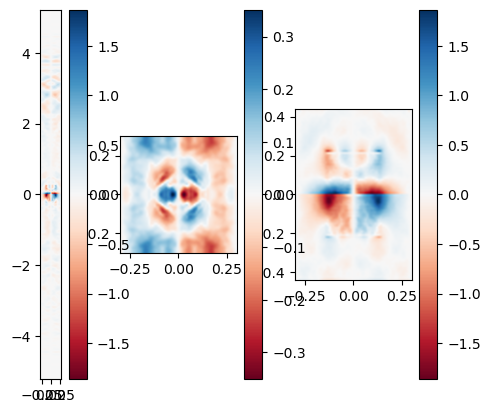

In [172]:


fig, ax = plt.subplots(1,3)

sim_center, sim_size = vis.get_2D_dimensions(
    sim, 
    mp.Volume(
        center = mp.Vector3(0,0,0), 
        size = mp.Vector3(sx, 0, sz)
    )
)
xmin, xmax, ymin, ymax, zmin, zmax = vis.box_vertices(
        sim_center, sim_size, False
    )
extent = [xmin, xmax, zmin, zmax]
field_data = np.rot90(np.real(sim.get_array(center=sim_center, size=sim_size, component=mp.Ez)))

image=ax[0].imshow(
    field_data, 
    extent=extent, 
    cmap="RdBu",
    norm = mpl.colors.CenteredNorm(halfrange=np.amax(field_data)),
    interpolation="spline36")
fig.colorbar(
    mappable=image
)

sim_center, sim_size = vis.get_2D_dimensions(
    sim, 
    mp.Volume(
        center = mp.Vector3(0,0,0), 
        size = mp.Vector3(sx, sy, 0)
    )
)
xmin, xmax, ymin, ymax, zmin, zmax = vis.box_vertices(
        sim_center, sim_size, False
    )
extent = [xmin, xmax, ymin, ymax]
field_data = np.rot90(np.real(sim.get_array(center=sim_center, size=sim_size, component=mp.Ez)))

image=ax[1].imshow(
    field_data, 
    extent=extent, 
    cmap="RdBu",
    norm = mpl.colors.CenteredNorm(halfrange=np.amax(field_data)),
    interpolation="spline36")
fig.colorbar(
    mappable=image
)
sim_center, sim_size = vis.get_2D_dimensions(
    sim, 
    mp.Volume(
        center = mp.Vector3(0,0,0), 
        size = mp.Vector3(sx, 0, 2*ph)
    )
)
xmin, xmax, ymin, ymax, zmin, zmax = vis.box_vertices(
        sim_center, sim_size, False
    )
extent = [xmin, xmax, zmin, zmax]
field_data = np.rot90(np.real(sim.get_array(center=sim_center, size=sim_size, component=mp.Ez)))

image=ax[2].imshow(
    field_data, 
    extent=extent, 
    cmap="RdBu",
    norm = mpl.colors.CenteredNorm(halfrange=np.amax(field_data)),
    interpolation="spline36")
fig.colorbar(
    mappable=image
)


In [173]:
a = "Hello"
b = "World"
c = a + " " +b
print(c)

Hello World


In [174]:
import pandas as pd
import os
params=pd.read_csv("parameter_space.csv")
params["max_angle"]

0    20
Name: max_angle, dtype: int64

-----------
Initializing structure...
time for choose_chunkdivision = 6.69956e-05 s
Working in 3D dimensions.
Computational cell is 4 x 4 x 24 with resolution 50
subpixel-averaging is 57.5036% done, 2.95615 s remaining
subpixel-averaging is 57.391% done, 2.96976 s remaining
subpixel-averaging is 57.7401% done, 2.92761 s remaining
time for set_epsilon = 22.7497 s
-----------
Meep: using complex fields.
Meep progress: 0.01/20.0 = 0.0% done in 14.1s, 28202.3s to go
on time step 1 (time=0.01), 14.1087 s/step
Meep progress: 0.11/20.0 = 0.5% done in 18.5s, 3340.2s to go
on time step 11 (time=0.11), 0.436267 s/step
Meep progress: 0.21/20.0 = 1.0% done in 22.5s, 2119.4s to go
on time step 21 (time=0.21), 0.401699 s/step
Meep progress: 0.31/20.0 = 1.5% done in 26.6s, 1689.1s to go
on time step 31 (time=0.31), 0.410304 s/step
Meep progress: 0.4/20.0 = 2.0% done in 30.9s, 1514.0s to go
on time step 40 (time=0.4), 0.478208 s/step
Meep progress: 0.49/20.0 = 2.4% done in 34.9s, 1390.4s to go
on time

NameError: name 'sim' is not defined

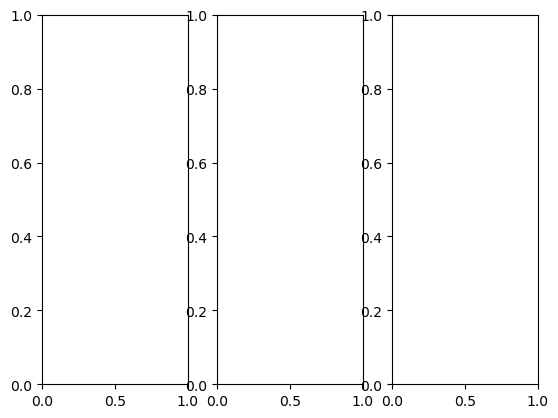

: 

In [ ]:
#"37.474057025", "0", f"{is_s}", f"{path}raw/", f"{height_um}", f"{rad_um}", "4", "4"


freq_THz = 37.474057025
angle_deg = 0
polarization_s = True
path = "results/260308/3d-grating"

ph=2 # pillar height
#pr=float(sys.argv[6]) # pillar radius
ppx=4 # unit cell x length
ppy=4 # unit cell y length

resolution = 50 # fdtd grid resolution

theta_r = math.radians(angle_deg) # convert angle to radians

fcen = freq_THz/300 # source center frequency (MEEP units)

dpml = 1 # perfectly matched layer thickness
dpad = 10 # thickness of glass above/below PhC

# cell dimensions
sx = ppx 
sy = ppy
sz = dpml + dpad + ph + dpad + dpml

cell_size = mp.Vector3(sx, sy, sz)

# cell Z boundary
pml_layers = [mp.PML(thickness=dpml, direction=mp.Z)]

k_point = mp.Vector3(0, 0, fcen * 1).rotate(mp.Vector3(0, 1, 0), theta_r)

src_pt = mp.Vector3(0,0, 0.5 * (sz - 2 * dpml - ph))
ref_mon_pt = mp.Vector3(0,0, 0.5 * (dpad + dpml))
trans_mon_pt = mp.Vector3(0,0, -0.5 * (ph + dpad + dpml))

default_material = mp.Medium(index = 1)

geometry_base=[
    
]
'''
geometry_trial = [
    mp.Block(
        material=mp.Medium(index=1.345),
        size=mp.Vector3(sx,sy,2),
        center=mp.Vector3(0,0,-(2+ph)/2)
    ),
    mp.Cylinder(
        material = mp.Medium(index=3.42),
        height = ph, 
        radius = pr, 
        axis = mp.Vector3(0,0,1), 
        center = mp.Vector3()
    )
]
'''
def pw_amp(k, x0):
    def _pw_amp(x):
        return cmath.exp(1j * 2 * math.pi * k.dot(x + x0))
    
    return _pw_amp


if polarization_s:
    sources = [
        mp.Source(
            mp.ContinuousSource(fcen), 
            component = mp.Ey, 
            center = src_pt,
            size = mp.Vector3(sx, sy, 0), 
            amp_func=pw_amp(k_point, src_pt)
        )
    ]
else:
    sources = [
        mp.Source(
            mp.ContinuousSource(fcen), 
            component = mp.Hy, 
            center = src_pt,
            size = mp.Vector3(sx, sy, 0), 
            amp_func=pw_amp(k_point, src_pt)
        )
    ]           


symmetries = []

sim_base = mp.Simulation(
    resolution=resolution,
    cell_size=cell_size,
    boundary_layers=pml_layers,
    k_point=k_point,
    sources=sources, 
    symmetries = symmetries, 
    default_material = default_material, 
    geometry=geometry_base
)

trans_flux = sim_base.add_flux(
    fcen, 
    0, 
    1, 
    mp.FluxRegion(center = trans_mon_pt, size = mp.Vector3(sx, sy, 0))
)

sim_base.run(until = 20)

b_flux = mp.get_fluxes(trans_flux)
print(b_flux)
'''
sim = mp.Simulation(
    resolution=resolution,
    cell_size=cell_size,
    boundary_layers=pml_layers,
    k_point=k_point,
    sources=sources, 
    default_material = default_material, 
    geometry=geometry_trial,
    symmetries = symmetries
)

trans_flux = sim.add_flux(
    fcen, 
    0, 
    1, 
    mp.FluxRegion(center = trans_mon_pt, size = mp.Vector3(sx, sy, 0))
)

#sim.run(until = 20)
'''

t_flux = mp.get_fluxes(trans_flux)
#Tflux = t_flux[0]/b_flux[0]

## plotting and storing results

fig, ax = plt.subplots(1,3)

### plot epsilon
vis.plot_eps(
    sim = sim, 
    ax = ax[0], 
    output_plane=mp.Volume(
        center = mp.Vector3(), 
        size = mp.Vector3(sx, 0, sz)),
    eps_parameters =  {
        "interpolation": "spline36",
        "cmap": "jet",
        "alpha": 1.0,
        "contour": False,
        "contour_linewidth": 1,
        "frequency": None,
        "resolution": None,
        "colorbar": True,
    }, 
    colorbar_parameters={
        "label": None,
        "orientation": "vertical",
        "extend": None,
        "position": "right",
        "size": "10%",
        "pad": "10%",
    }
    
)

### plot vertical slice of fields
sim_center_1, sim_size_1 = vis.get_2D_dimensions(
    sim, 
    mp.Volume(
        center = mp.Vector3(0,0,0), 
        size = mp.Vector3(sx, 0, (sz - 2 * dpml - ph)-0.1)
    )
)
xmin, xmax, ymin, ymax, zmin, zmax = vis.box_vertices(
        sim_center_1, sim_size_1, False
    )
extent_1 = [xmin, xmax, zmin, zmax]

if polarization_s:
    field_data_1 = np.rot90(np.real(sim.get_array(center=sim_center_1, size=sim_size_1, component=mp.Ey)))
else:
    field_data_1 = np.rot90(np.real(sim.get_array(center=sim_center_1, size=sim_size_1, component=mp.Hy)))

image_1=ax[1].imshow(
    field_data_1, 
    extent=extent_1, 
    cmap="RdBu",
    norm = mpl.colors.CenteredNorm(halfrange=np.amax(field_data_1)),
    interpolation="spline36")
fig.colorbar(
    mappable=image_1
)
ax[1].set_xlabel("X")
ax[1].set_ylabel("Z")
ax[1].set_xticks([-0.3,0,0.3])

### plot horizontal slice of fields
sim_center_2, sim_size_2 = vis.get_2D_dimensions(
    sim, 
    mp.Volume(
        center = mp.Vector3(0,0,0), 
        size = mp.Vector3(sx, sy, 0)
    )
)
xmin, xmax, ymin, ymax, zmin, zmax = vis.box_vertices(
        sim_center_2, sim_size_2, False
    )
extent_2 = [xmin, xmax, ymin, ymax]

if polarization_s:
    field_data_2 = np.rot90(np.real(sim.get_array(center=sim_center_2, size=sim_size_2, component=mp.Ey)))
else:
    field_data_2 = np.rot90(np.real(sim.get_array(center=sim_center_2, size=sim_size_2, component=mp.Hy)))

image_2=ax[2].imshow(
    field_data_2, 
    extent=extent_2, 
    cmap="RdBu",
    norm = mpl.colors.CenteredNorm(halfrange=np.amax(field_data_2)),
    interpolation="spline36")
fig.colorbar(
    mappable=image_2
)
ax[2].set_xlabel("X")
ax[2].set_ylabel("Y")

plt.tight_layout()

fig.savefig(f"{path}{ph}-{pr}.png")

out_data = {
    "ph": [ph], 
    "pr": [pr], 
    "trans": [t_flux]
}

out = pd.DataFrame(out_data)
out.to_csv(f"{path}{ph}-{pr}.csv", index = False)




  